<center><h1>An Introduction to OpenFace for Head and Face Tracking </h1>


<h3> James Trujillo ( j.p.trujillo@uva.nl)<br>
    Anna Palmann (a.palmann@uva.nl)<br>
    01-07-2026 </h3>
    
<img src="./images/EnvisionBox_New_Logo_White.jpg" width="300"> </center>

<h3> Info documents </h3>
This Python coding module demonstrates how to use OpenFace, an open-source program that provides face and head tracking of images or videos. In the first part of this module, we'll go over basic installation, simple commands to run the tracking, and get a first look at the output data.
<br>
In the second part, we'll go into some basic analyses of face and head data.<br>

* OpenFace: https://github.com/TadasBaltrusaitis/OpenFace
* citation: OpenFace 2.0: Facial Behavior Analysis Toolkit Tadas Baltrušaitis, Amir Zadeh, Yao Chong Lim, and Louis-Philippe Morency, IEEE International Conference on Automatic Face and Gesture Recognition, 2018

* Visual Studio download (VS required to run OpenFace via command line): https://visualstudio.microsoft.com/thank-you-downloading-visual-studio/?sku=Community&rel=17

* A detailed tutorial for using ExploFace: https://github.com/emrecdem/exploface/blob/master/TUTORIALS/tutorial1.ipynb 

* location code: 
[ TO BE ADDED ]

<h3>Notes on Running this notebook</h3>
Exploface has many dependencies that do not work on new versions of Python. We therefore recommend that you use an older version, and follow the package versions listed in requirements.txt. This notebook was created in <b>Python 3.9</b>.<br>
* packages to download:
  
-<i> pandas </i>

-<i> exploface </i>

-<i> scipy</i>

-<i> pympi-ling</i>

-<i> praat-parselmouth</i>

(note that you can also download all required packages using <i>pip install -r requirements.txt</i>

* citation: 
Trujillo, J.P. & Anna Palmann (01-07-2026). <i>  An Introduction to OpenFace for Head and Face Tracking</i> \[day you visited the site]. https://envisionbox.org/embedded_OpenFace_module



<h3> Installing OpenFace </h3>

* Download the latest binaries from https://github.com/TadasBaltrusaitis/OpenFace/wiki/Windows-Installation 

* Unzip the folder into a directory of your choosing -- we recommend unzipping into the FaceTracking_OpenFace directory
    
* You will also need to download the models that OpenFace uses for Feature Detection.
  This can be done using powershell (search in your taskbar for powershell, right-click --> Run as administrator

* Navigate to the OpenFace directory (the one that you unzipped. Probably something like <i>OpenFace_2.2.0_*</i>)
* Run:  <i> powershell -ExecutionPolicy Bypass -File .\download_models.ps1</i>

 You won't see anything directly under your command after running it, but the top of the window should show that your system is downloading it
  <img src="./images/powershell.png"> </center>

<h3> Running OpenFace </h3>

* <b> To run offline </b>, using a GUI, you can navigate to the main folder and run double-click OpenFaceDemo.exe

* <b> To run via command line </b>, you need a cmd prompt open to the OpenFace directory
For example, I have cmd line running in <i>D:\data\MoCap\OpenFace_2.2.0_win_x64\OpenFace_2.2.0_win_x64</i>


<i>FeatureExtraction.exe</i> is the main function for processing single faces
<i>FaceLandmarkVidMulti.exe</i> is used when there are multiple faces

For example, to run OF on the sample video provided, we can type the following in cmd:
<i>D:\
FeatureExtraction.exe -f "./samples/2015-10-15-15-14.avi"</i>
OpenFace will update you on the progress
<img src="./images/OF_running.png"></center>

<br> By default, you get a folder in the OpenFace directory called <i>processed</i> where all the output is stored. However, this means all output .csv files, video files, etc are all thrown in one folder. If you don't want this, you can specify an output directory by adding the following to the FeatureExtraction command:
<i>-out_dir "output_path"</i> 
<br>
<b> Timing </b>
Depending on your machine, OF takes approximately the duration of your video +20% 
<br><br>
However, you probably want to process multiple files in a batch. For this, we can use the python code below. It uses the same commands shown here, but runs them via Python. We loop through each video in the <i>videos_to_process</i> folder, create a new output folder for the results in <i>OF_output</i>, and then process the video.

In [1]:
from pathlib import Path
import subprocess
import os

# Main directories
VIDEO_DIR = "./videos_to_process/"
OUTPUT_DIR =  "./OF_output/"

In [ ]:
# Find the OpenFace directory (e.g. OpenFace_2.2.0_win_x64)
openface_dir = "./OpenFace_2.2.0_win_x64/"

# Path to FeatureExtraction.exe
feature_exe = openface_dir + "FeatureExtraction.exe"

# Video extensions to process
VIDEO_EXTENSIONS = {"mp4", "avi", "mov", "mkv", "wmv", "mpeg"}

failed = []

for filename in os.listdir(VIDEO_DIR):
    video_path = os.path.join(VIDEO_DIR, filename)
    
    if video_path.split('.')[-1].lower() not in VIDEO_EXTENSIONS:
        continue
    # make the output folder
    output_path = OUTPUT_DIR + filename.split('.')[0]

    # Skip if the video has already been processed
    if os.path.isdir(output_path):
        print(f"Skipping {filename} (already processed)")
        continue
        
    os.mkdir(output_path)

    print(f"\nProcessing {filename}...")

    # this part actually runs the .exe file for us, assembling the complete call that
    # includes the output path and video name
    try: 
        subprocess.run(
            [
                str(feature_exe),
                "-f",
                str(video_path),
                "-out_dir",
                str(output_path),
            ],
            capture_output=True,
            text=True,
        )

    except subprocess.CalledProcessError as e:
        print(f"Failed ({e.returncode})")
        failed.append(filename)

    except Exception as e:
        print(f"Unexpected error: {e}")
        failed.append(filename)

print("\nFinished processing.")

if failed:
    print("\nThe following files failed:")
    for name in failed:
        print(f"  - {name}")
else:
    print("All videos processed successfully.")


Processing 103_203_12_1_20250113_152455_doughnut_board_clueGiver_cam01.mp4...

Processing 103_203_12_1_20250113_152455_doughnut_board_clueGiver_cam02.mp4...

Processing 103_203_12_1_20250113_152455_doughnut_board_guesser_cam01.mp4...

Processing 103_203_12_1_20250113_152455_doughnut_board_guesser_cam02.mp4...

Processing 103_203_13_1_20250113_152513_spinach_board_clueGiver_cam01.mp4...

Processing 103_203_13_1_20250113_152513_spinach_board_clueGiver_cam02.mp4...

Processing 103_203_13_1_20250113_152513_spinach_board_guesser_cam01.mp4...

Processing 103_203_13_1_20250113_152513_spinach_board_guesser_cam02.mp4...

Processing 103_203_14_1_20250113_152536_balloon_board_clueGiver_cam01.mp4...

Processing 103_203_14_1_20250113_152536_balloon_board_clueGiver_cam02.mp4...

Processing 103_203_14_1_20250113_152536_balloon_board_guesser_cam01.mp4...

Processing 103_203_14_1_20250113_152536_balloon_board_guesser_cam02.mp4...

Processing 103_203_15_1_20250113_152557_bacon_board_clueGiver_cam01.mp4

<h3> OpenFace Output </h3>
OpenFace provides several types of output, including a video visualizing the tracking, as well as a .csv containing coordinate data, rotation data, and action units.

First, let's take a look at the output video. How does it perform? You should be thinking about the types of questions you want to ask using your data, and take a critical look at whether the tracking is sensitive and accurate enough to serve your purpose. Remember that (some) jitter can be removed with smoothing!

Now, let's take a look at the numerical data, and what was actually tracked. <br>
<b> Action Units</b><br>
OpenFace recognizes a subset of all possible action units. These include:
* 1: inner brow raiser
* 2: outer brow raiser
* 4: brow lowerer
* 5: upper lid raiser
* 6: cheek raiser
* 7: lid tightener
* 9: nose wrinkler 
* 10: upper lip raiser
* 12: lip corner puller (smile)
* 14: dimpler
* 15: lip corner depressor (sad)
* 17: chin raiser
* 20: lip stretcher
* 23: lip tightener
* 25: lips part
* 26: jaw drop
* 28: lip suck – only presence, not intensity
* 45: blink
<img src="./images/AUs.jpg"></center>
<br> 
OpenFace provides two sets of columns for these AUs. 

* Presence: given in the AU*_c columns, this just indicates whethere the AU is present in a given frame
* Intensity: given in the AU*_r columns, this provides an indication of the intensity of the action unit
NOTE: these two values are estimated by two different models, which means sometimes there is no AU detected, but intensity != 0
<br>
<b> Facial Landmark Coordinates </b><br>
We also have facial landmark locations. For each of these 68 landmarks gets at least 4 values: tracking confidence (0-1), tracking success (binary - was anything tracked?), as well as an x and y location, given in pixels
<img src="./images/landmark_scheme_68.png"></center>
<br>
<b>Head Pose </b><br>
We also get the relative pose of the head. This is provided in <i>Translation</i>, which gives the location of the head with respect to the camera centre, given in millimiters. We also get <i>Rotation</i> which proves the rotation of the head in radians around the 3 axes<br>
* <b>Pitch</b> is the head rotating "up and down" (nodding)
* <b>Roll</b> is the head tilting side to side (ear to shoulder)
* <b>Yaw</b> is the head turning left and right (looking over the shoulder) 
<br>
<b>Eye Gaze</b><br>
OpenPose also provides an estimation of the looking direction of the the eyes. This is given in gaze direction, as well as eye landmarks (similar to the facial landmark x,y coordinates).<br>
You get both vector coordinates for the eyes (gaze_0_x/y) as well as angular direction (gaze_angle_x/y). <br>
Good to know: <br>
* all values are given in world coordinates (not relative to head)
* angular values will be close to 0 if person is looking straight ahead
* angle_x = left to right; angle_y = up and down



Rather than write our own scripts to summarize different aspects of the data, we can make use of ExploFace to do much of this
(remember to install exploface before running! <i>pip install exploface</i>

<h3> Importing OpenFace into ELAN Using ExploFace </h3>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import exploface
import glob

for out_path in os.listdir(OUTPUT_DIR):
    output_filename = glob.glob(OUTPUT_DIR + out_path + "/*.csv")[0]
    # we'll stop here, just to get an example file
    break
    

openface_features = exploface.get_feature_time_series(output_filename)


This first command just gets the .csv file and loads into a dataframe. This can be a useful starting point if you want to run further analyses.<br>
Full a full list of what the different columns correspond to, you can check the OpenFace 2.0 Github page: https://github.com/TadasBaltrusaitis/OpenFace/wiki/Output-Format 

In [3]:
openface_features.head(5)

,frame,face_id,timestamp,confidence,success,gaze_0_x,gaze_0_y,gaze_0_z,gaze_1_x,gaze_1_y,...,AU12_c,AU14_c,AU15_c,AU17_c,AU20_c,AU23_c,AU25_c,AU26_c,AU28_c,AU45_c
0,1,0,0.000,0.98,1,-0.006234,0.298764,-0.954307,-0.140020,0.296120,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,0,0.033,0.98,1,-0.017089,0.299521,-0.953937,-0.142771,0.296794,...,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,3,0,0.067,0.98,1,-0.031182,0.299076,-0.953720,-0.156300,0.294212,...,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,4,0,0.100,0.98,1,-0.047156,0.301235,-0.952383,-0.172830,0.296094,...,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,5,0,0.133,0.98,1,-0.059206,0.305736,-0.950274,-0.183550,0.300213,...,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


Exploface can do a bit more than this though. A useful feature here is to get some summary statistics of what's happening in your video.

In [4]:
stats_df = exploface.get_statistics(output_filename)
stats_df

,nr_detections,average_length_detection,std_average_length_detection
AU01,2,1.115000,0.445477
AU02,2,0.815000,0.120208
AU04,6,1.866667,1.465942
AU05,4,3.065000,5.626091
AU06,1,0.640000,NaN
AU07,2,6.780000,0.212132
AU10,8,0.876250,0.935245
AU12,6,1.151667,0.767344
AU14,1,13.800000,NaN
AU15,4,0.590000,0.386868


Here we see the Action Unit detections, along with how many there were of each one, and their durations.
<br>
One of the nicer features here is that we can also convert these .csv data into a .eaf file for use in ELAN. We could then import these annotations into ELAN for further checking/cleaning, or for further analysis in ELAN itself.

In [5]:

feature_detections = exploface.get_detections(
                                            openface_features,
                                            skip_seconds_at_end=0,
                                            intensity_threshold=0.8,
                                            time_threshold=0.1,
                                            smooth_time_threshold = 0.1,
                                            uncertainty_threshold=0.9
                                             )

video_file = glob.glob(VIDEO_DIR +out_path + ".mp4")[0]

dataframe_timestamp = exploface.write_elan_file(feature_detections,
                                                  video_path=video_file,
                                                  output_path="sample_vid.eaf",
                        )

<h3>Potential Applications</h3>

* Speech-(head)gesture coupling
* Automatic gaze detection (who's looking at whom when?)
* Others?

<h3> Notes on Reliability </h3>

OpenFace provides some very useful output, and tracking quality seems to be good. However, note that you shouldn't take the output as true until you check it. <br>
In particular, many studies use the AU output without any (or very little) quality control. However, a corpus project looking at facial signals in conversation (see Nota et al., 2021; https://doi.org/10.3390/brainsci11081017 ) attempted to use OpenFace, but went with manual coding for most features instead, as AU detection is far from 100% accurate. It can be an interesting starting point to explore data, but the explicit detections absolutely <i>must</i> be checked and cleaned. <br> For a more in-depth discussion of these issues, and some tips on how to tune Exploface thresholds to get more reliable output, see Nota, Trujillo & Holler, 2026: https://osf.io/dtz5p/ 

<center><h1> Part 2: Data Analysis </h1>

This coding module gives an introduction to using the output of OpenFace together with prosodic data. We'll discuss cleaning the data, extracting relevant features, merging kinematic data with annotation data, and using Parselmouth (a python interface for working with Praat) to extract prosodic features from the audio stream. Finally, we'll perform a simple analysis of kinematic-prosodic alignment.
<br><br>

First, let's load in the data and apply some smoothing.

In [7]:
from scipy import signal

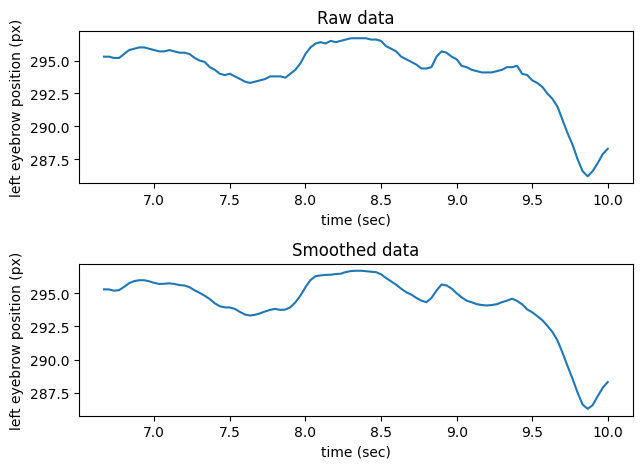

In [8]:
# let's compare raw and smoothed position
plt.subplot(2,1,1)
plt.plot(openface_features.loc[200:300,"timestamp"],openface_features.loc[200:300,"y_24"])
plt.xlabel("time (sec)")
plt.ylabel("left eyebrow position (px)")
plt.title("Raw data")
plt.subplot(2,1,2)
plt.plot(openface_features.loc[200:300,"timestamp"],signal.savgol_filter(openface_features.loc[200:300,"y_24"],5,3))
plt.xlabel("time (sec)")
plt.ylabel("left eyebrow position (px)")
plt.title("Smoothed data")
plt.tight_layout()
plt.show()

As we see above, the smoothing helps to iron our some of the jitter that is inherent to video based tracking, without affecting the main shape of the signal. <br>
Before we go on to any analysis, we need to get a time-series that is useful for us. In this case, we currently only have the position of the eyebrow landmarks in pixel space. This isn't always helpful, as movement of the head will also affect this position, and (at least for A/V coupling) we are mostly interested in kinematics, not position.<br>
- UNDER CONSTRUCTION -
  * Multimodal Face-Prosody Analysis Using OpenFace and Parselmouth
  * Comparison of OpenFace 2.2 and 3.0